## PRÁCTICA 3: Aprendizaje por refuerzo

##### Importamos el entorno

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

env = gym.make("Pendulum-v1", render_mode="rgb_array", g=9.81)  # default g=10.0

##### Mostramos el entorno

In [ ]:
obs, _ = env.reset()

print("Observación inicial:", obs)


##### Discretizamos las acciones

In [ ]:
NUM_ACCIONES = 20
acciones = np.linspace(-2, 2, NUM_ACCIONES)  # 5 acciones discretas

##### Creamos la clase Estado

In [ ]:
from collections import namedtuple

Estado = namedtuple('Estado', ['cos', 'sin', 'vel'])

def get_estado(obs):
    return Estado(obs[0], obs[1], obs[2])


##### Discretizamos los estados

In [ ]:
NUM_INTERVALOS = 20

cos_intervalos = np.linspace(-1, 1, NUM_INTERVALOS)
sin_intervalos = np.linspace(-1, 1, NUM_INTERVALOS)
vel_intervalos = np.linspace(-8, 8, NUM_INTERVALOS)

In [ ]:
def discretizar_estado(obs):
    cos_t, sin_t, vel = obs

    # la función np.digitize(valor, bins) asigna un valor a su intervalo correspondiente
    i = np.digitize(cos_t, cos_intervalos) - 1
    j = np.digitize(sin_t, sin_intervalos) - 1
    k = np.digitize(vel, vel_intervalos) - 1

    i = np.clip(i, 0, NUM_INTERVALOS-1)
    j = np.clip(j, 0, NUM_INTERVALOS-1)
    k = np.clip(k, 0, NUM_INTERVALOS-1)

    return (i, j, k)

In [ ]:
obs, _ = env.reset()

estado = get_estado(obs)
estado_discreto = discretizar_estado(obs)

print("Estado continuo:", estado)
print("Estado discreto:", estado_discreto)

## Montecarlo

##### Creamos política aleatoria de prueba

In [8]:
politica_aleatoria = np.ones((NUM_INTERVALOS, NUM_INTERVALOS, NUM_INTERVALOS, NUM_ACCIONES)) / NUM_ACCIONES

In [9]:
def muestrea_politica(estado, politica):
    cos_bin, sin_bin, vel_bin = estado

    probs = politica[cos_bin, sin_bin, vel_bin]

    np.testing.assert_almost_equal(np.sum(probs), 1.0, err_msg='La política para un estado siempre debe sumar 1')

    accion_idx = np.random.choice(NUM_ACCIONES, p=probs)

    return accion_idx

obs, _ = env.reset()
estado = discretizar_estado(obs)

accion_idx = muestrea_politica(estado, politica_aleatoria)
accion = np.array([acciones[accion_idx]])

print("Estado:", estado)
print("Acción escogida:", accion)

obs, reward, terminated, truncated, info = env.step(accion)

print("Obs:", obs)
print("Reward:", reward)

Estado: (np.int64(0), np.int64(7), np.int64(8))
Acción escogida: [1.15789474]
Obs: [-0.9899238  -0.14160144 -0.7834866 ]
Reward: -8.83293685810689


##### Simulamos episodio

In [13]:
def simula_episodio(politica: np.ndarray, imprime: bool = False):

    obs, _ = env.reset()
    estado_actual = discretizar_estado(obs)

    completado = False
    contador = 0
    retorno = 0
    recorrido = []

    MAX_STEPS = 200  # Pendulum no termina solo

    while not completado and contador < MAX_STEPS:

        accion_idx = muestrea_politica(estado_actual, politica)
        accion = np.array([acciones[accion_idx]])
        obs, recompensa, terminated, truncated, info = env.step(accion)

        nuevo_estado = discretizar_estado(obs)
        recorrido.append((estado_actual, accion_idx, recompensa))
        retorno += recompensa
        contador += 1

        estado_actual = nuevo_estado
        completado = terminated or truncated or (contador >= MAX_STEPS)

        if imprime:
            print("Paso:", contador)
            print("Acción idx:", accion_idx)
            print("Acción real:", accion)
            print("Estado:", estado_actual)
            print("Recompensa:", recompensa)

    return retorno, contador, recorrido

retorno, num_pasos, recorrido = simula_episodio(politica_aleatoria, imprime=False)
print(f'Simulado un episodio con retorno = {retorno} y pasos = {num_pasos}')

retorno, num_pasos, recorrido = simula_episodio(politica_aleatoria, True)

print('Recorrido:', recorrido)

Simulado un episodio con retorno = -1448.9062525229524 y pasos = 200
Recorrido: [((np.int64(18), np.int64(13), np.int64(8)), 0, np.float64(-0.16704005961613994)), ((np.int64(18), np.int64(12), np.int64(8)), 12, np.float64(-0.14890291636740258)), ((np.int64(18), np.int64(12), np.int64(9)), 9, np.float64(-0.12517707134832648)), ((np.int64(18), np.int64(12), np.int64(9)), 11, np.float64(-0.12955318280768377)), ((np.int64(18), np.int64(13), np.int64(10)), 10, np.float64(-0.16172154072770548)), ((np.int64(18), np.int64(13), np.int64(10)), 16, np.float64(-0.2246358338458136)), ((np.int64(17), np.int64(13), np.int64(10)), 5, np.float64(-0.3743994639045186)), ((np.int64(17), np.int64(14), np.int64(11)), 11, np.float64(-0.49662235725544635)), ((np.int64(17), np.int64(15), np.int64(11)), 3, np.float64(-0.7466280055244927)), ((np.int64(16), np.int64(15), np.int64(11)), 5, np.float64(-0.9795027841198588)), ((np.int64(15), np.int64(16), np.int64(12)), 14, np.float64(-1.3335986524470391)), ((np.int6

##### Comprobación del rendimiento de la política

0 - Simulado un episodio con retorno -1214.0625528279734 y número de pasos = (200)
1 - Simulado un episodio con retorno -1176.1213941343653 y número de pasos = (200)
2 - Simulado un episodio con retorno -973.4478962229234 y número de pasos = (200)
3 - Simulado un episodio con retorno -1787.7805932194099 y número de pasos = (200)
4 - Simulado un episodio con retorno -1297.4631337755404 y número de pasos = (200)
5 - Simulado un episodio con retorno -1074.3240216702802 y número de pasos = (200)
6 - Simulado un episodio con retorno -1424.8483993944487 y número de pasos = (200)
7 - Simulado un episodio con retorno -994.7899035877846 y número de pasos = (200)
8 - Simulado un episodio con retorno -1188.4089915164548 y número de pasos = (200)
9 - Simulado un episodio con retorno -1551.15514273011 y número de pasos = (200)
10 - Simulado un episodio con retorno -875.8425719269093 y número de pasos = (200)
11 - Simulado un episodio con retorno -930.6087914163434 y número de pasos = (200)
12 - Sim

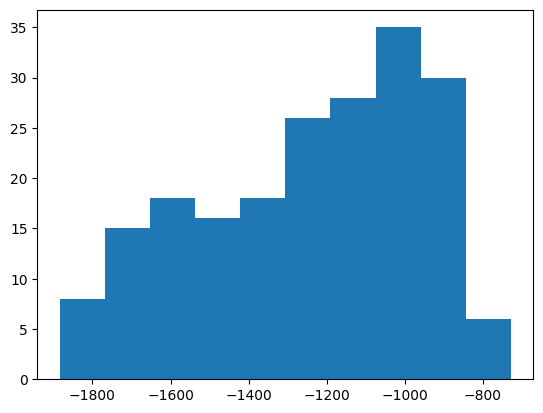

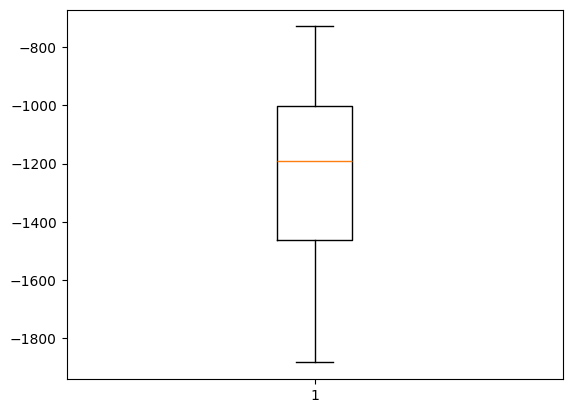

En cada paso se ha obtenido de media un retorno de  -1243.8486379088247 (+- 290.04179205662456 )
El retorno más pequeño fue -1883.2864729130463 y el retorno más grande fue -728.7816146971121


In [14]:
def comprueba_politica(politica:np.ndarray, imprime:bool = False) -> None:
    episodios_retornos = []
    for i in range(200):
        retorno, num_pasos, recorrido = simula_episodio(politica, imprime)
        episodios_retornos.append(retorno)
        print(f'{i} - Simulado un episodio con retorno {retorno} y número de pasos = ({num_pasos})')

    # histograma para los retornos
    plt.hist(episodios_retornos)
    plt.show()

    # diagrama de caja
    plt.boxplot(episodios_retornos)
    plt.show()

    # estadísticas de media y desviación típica
    print('En cada paso se ha obtenido de media un retorno de ',np.mean(episodios_retornos),'(+-',np.std(episodios_retornos),')')
    print('El retorno más pequeño fue',np.min(episodios_retornos),'y el retorno más grande fue',np.max(episodios_retornos))

comprueba_politica(politica_aleatoria)

# Evaluación de la política

##### Montecarlo (ϵ-soft on-policy)

0 - Simulado un episodio con retorno -487.96687454587686 y número de pasos = (200)
1 - Simulado un episodio con retorno -567.1030134320179 y número de pasos = (200)
2 - Simulado un episodio con retorno -610.5864640634987 y número de pasos = (200)
3 - Simulado un episodio con retorno -1147.7794474900536 y número de pasos = (200)
4 - Simulado un episodio con retorno -486.2832916308558 y número de pasos = (200)
5 - Simulado un episodio con retorno -867.6931547860444 y número de pasos = (200)
6 - Simulado un episodio con retorno -1104.9898512156783 y número de pasos = (200)
7 - Simulado un episodio con retorno -750.8528937687942 y número de pasos = (200)
8 - Simulado un episodio con retorno -740.1531784847824 y número de pasos = (200)
9 - Simulado un episodio con retorno -742.3009698290434 y número de pasos = (200)
10 - Simulado un episodio con retorno -625.4096226984582 y número de pasos = (200)
11 - Simulado un episodio con retorno -629.9520569982915 y número de pasos = (200)
12 - Simula

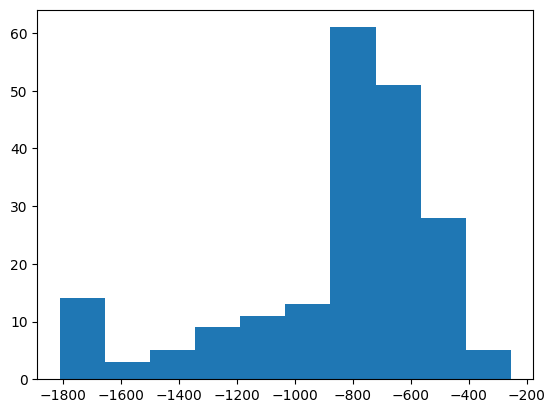

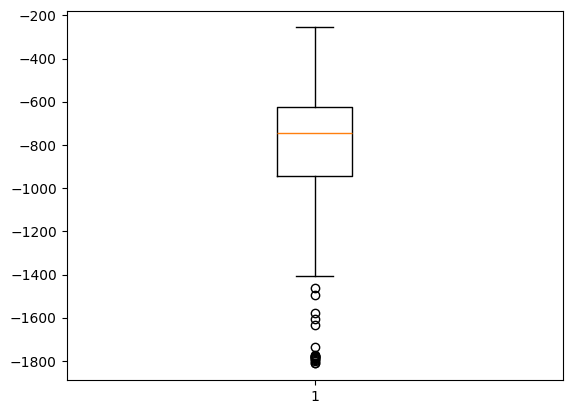

En cada paso se ha obtenido de media un retorno de  -844.0620494832133 (+- 357.12877836303664 )
El retorno más pequeño fue -1811.1296961587339 y el retorno más grande fue -255.54594074089374


In [22]:
GAMMA = 1.0

def mc_control(num_pasos:int=20000, epsilon:float=0.2) -> np.ndarray:

    qsa = np.zeros((20, 20, 20, NUM_ACCIONES))
    politica = np.zeros((20, 20, 20, NUM_ACCIONES))
    # Partimos de la política aleatoria
    politica[:] = 1.0 / NUM_ACCIONES

    retornos = [[[ [ [] for _ in range(NUM_ACCIONES)]
                   for _ in range(qsa.shape[2])]
                   for _ in range(qsa.shape[1])]
                   for _ in range(qsa.shape[0])]

    for episodio in range(num_pasos):
        ep_retorno, ep_num_pasos, ep_recorrido = simula_episodio(politica)
        g = 0
        estados_acciones_vistos = []

        for (i, j, k), accion, recompensa in reversed(ep_recorrido):
            g = recompensa + GAMMA * g

            if (i,j,k,accion) not in estados_acciones_vistos:
                estados_acciones_vistos.append((i,j,k,accion))

                retornos[i][j][k][accion].append(g)

                qsa[i,j,k,accion] = np.mean(retornos[i][j][k][accion])

                # política ε-soft
                mejor_accion = np.argmax(qsa[i,j,k,:])

                for a in range(NUM_ACCIONES):
                    if a == mejor_accion:
                        politica[i,j,k,a] = 1 - epsilon + epsilon / NUM_ACCIONES
                    else:
                        politica[i,j,k,a] = epsilon / NUM_ACCIONES

    return politica              # debería devolver crea_politica_avara(politica)


# Calculamos la política usando un epsilon de 0.4 para garantizar la exploración
politica_montecarlo_es = mc_control(epsilon=0.4)
comprueba_politica(politica_montecarlo_es)


### SARSA

In [ ]:
GAMMA = 0.9

def get_accion_epsilon_greedy(q_valores_acciones:np.ndarray, epsilon:float):
    if np.random.random()<epsilon:
        return np.random.randint(0, NUM_ACCIONES)
    return np.argmax(q_valores_acciones)


In [26]:
def sarsa(num_episodios:int = 50000, ALPHA:float = 0.1, EPSILON:float = 0.25, decay = 0.5) -> np.ndarray:
    q_valores = np.zeros((NUM_INTERVALOS, NUM_INTERVALOS, NUM_INTERVALOS, NUM_ACCIONES))
    retornos = []
    media_movil = []
    cnt = 0
    while cnt < num_episodios:
        cnt += 1
        retorno = 0
        num_pasos = 0
        completado = False
        env.reset()
        env.max_steps = 200
        estado_actual = discretizar_estado(obs)
        accion_escogida = get_accion_epsilon_greedy(q_valores[*estado_actual, :], EPSILON * decay ** num_episodios)
        while not completado:
            valores_acciones = q_valores[*estado_actual, :]
            observacion, recompensa, terminated, truncated, info = env.step(np.array([acciones[accion_escogida]]))
            nuevo_estado = discretizar_estado(observacion)
            nuevos_valores_acciones = q_valores[*nuevo_estado, :]
            nueva_accion = get_accion_epsilon_greedy(nuevos_valores_acciones, EPSILON * decay ** num_episodios)
            retorno += recompensa
            num_pasos += 1
            completado = terminated or truncated
            valor_actual = valores_acciones[accion_escogida]
            nuevo_valor = nuevos_valores_acciones[nueva_accion]
            q_valores[*estado_actual, accion_escogida] = valor_actual + ALPHA * (recompensa + GAMMA * nuevo_valor - valor_actual)

            # print("Número de paso: ", num_pasos)
            # print("Episodio: ", cnt)
            # print("Acción aplicada: ", accion_escogida)
            # print("Estado resultante: ", estado_actual, observacion)
            # print("Recompensa obtenida: ", recompensa)
            # print("Ejecución completada? ", completado)

            estado_actual = nuevo_estado
            accion_escogida = nueva_accion
        media_movil.append(retorno)
        if len(media_movil)==1001: # ... y si hay ya más de 100...
            media_movil.pop(0) # ...quitamos el más antiguo (para tener siempre 100, no más)...
            retornos.append(np.mean(media_movil))
        print(f'Terminado episodio {cnt} con retorno {retorno} en {num_pasos} pasos')
    return q_valores, retornos

# Entrenamos al agente usando los parámetros por defecto de la función que acabamos de definir
q_valores_sarsa = sarsa()

Terminado episodio 1 con retorno -1628.2953919881109 en 200 pasos
Terminado episodio 2 con retorno -1415.5023090856234 en 200 pasos
Terminado episodio 3 con retorno -1383.5704832509207 en 200 pasos
Terminado episodio 4 con retorno -1506.8090352132438 en 200 pasos
Terminado episodio 5 con retorno -1571.5489185883541 en 200 pasos
Terminado episodio 6 con retorno -1410.3489644526728 en 200 pasos
Terminado episodio 7 con retorno -1131.6979449050664 en 200 pasos
Terminado episodio 8 con retorno -1720.568059088428 en 200 pasos
Terminado episodio 9 con retorno -1348.3730835317244 en 200 pasos
Terminado episodio 10 con retorno -1459.0165525963714 en 200 pasos
Terminado episodio 11 con retorno -1196.038838922667 en 200 pasos
Terminado episodio 12 con retorno -1212.9980461138334 en 200 pasos
Terminado episodio 13 con retorno -1746.924887522698 en 200 pasos
Terminado episodio 14 con retorno -1023.6401870048004 en 200 pasos
Terminado episodio 15 con retorno -1707.3597295959732 en 200 pasos
Termina

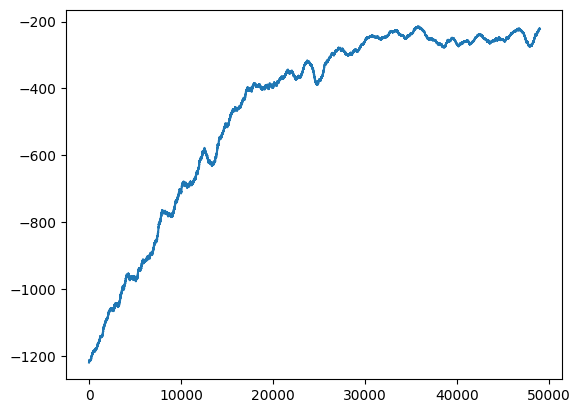

In [27]:
plt.plot(q_valores_sarsa[1])

#### Qlearning

In [ ]:
def qlearning(num_episodios:int = 50000, ALPHA:float = 0.1, EPSILON:float = 0.25) -> np.ndarray:
    q_valores = np.zeros((NUM_INTERVALOS, NUM_INTERVALOS, NUM_INTERVALOS, NUM_ACCIONES))
    retornos = []
    media_movil = []
    cnt = 0
    while cnt < num_episodios:
        cnt += 1
        retorno = 0
        num_pasos = 0
        completado = False
        env.reset()
        env.max_steps = 200
        estado_actual = discretizar_estado(obs)
        while not completado:
            accion_escogida = get_accion_epsilon_greedy(q_valores[*estado_actual, :], EPSILON)
            valores_acciones = q_valores[*estado_actual, :]
            observacion, recompensa, terminated, truncated, info = env.step(np.array([acciones[accion_escogida]]))
            nuevo_estado = discretizar_estado(observacion)
            nuevos_valores_acciones = q_valores[*nuevo_estado, :]
            retorno += recompensa
            num_pasos += 1
            completado = terminated or truncated
            valor_actual = valores_acciones[accion_escogida]
            q_valores[*estado_actual, accion_escogida] = valor_actual + ALPHA * (recompensa + GAMMA * np.max(nuevos_valores_acciones) - valor_actual)

            # print("Número de paso: ", num_pasos)
            # print("Episodio: ", cnt)
            # print("Acción aplicada: ", accion_escogida)
            # print("Estado resultante: ", estado_actual, observacion)
            # print("Recompensa obtenida: ", recompensa)
            # print("Ejecución completada? ", completado)

            estado_actual = nuevo_estado

        media_movil.append(retorno)
        if len(media_movil)==1001: # ... y si hay ya más de 100...
            media_movil.pop(0) # ...quitamos el más antiguo (para tener siempre 100, no más)...
            retornos.append(np.mean(media_movil))
        print(f'Terminado episodio {cnt} con retorno {retorno} en {num_pasos} pasos')
    return q_valores, retornos
qlearning_valores = qlearning()

Terminado episodio 1 con retorno -1308.8778271890546 en 200 pasos 
Terminado episodio 2 con retorno -1504.3948009498024 en 200 pasos 
Terminado episodio 3 con retorno -1529.1533137027736 en 200 pasos 
Terminado episodio 4 con retorno -1402.4222903644616 en 200 pasos 
Terminado episodio 5 con retorno -1602.7099809130261 en 200 pasos 
Terminado episodio 6 con retorno -1293.5020110287317 en 200 pasos 
Terminado episodio 7 con retorno -1149.6777829904531 en 200 pasos 
Terminado episodio 8 con retorno -1434.16926828125 en 200 pasos 
Terminado episodio 9 con retorno -1216.0302742062274 en 200 pasos 
Terminado episodio 10 con retorno -1196.0311698451167 en 200 pasos 
Terminado episodio 11 con retorno -1704.5785670842934 en 200 pasos 
Terminado episodio 12 con retorno -1062.5086442685356 en 200 pasos 
Terminado episodio 13 con retorno -994.5898653677871 en 200 pasos 
Terminado episodio 14 con retorno -956.4389813382995 en 200 pasos 
Terminado episodio 15 con retorno -1516.6629594491258 en 200 

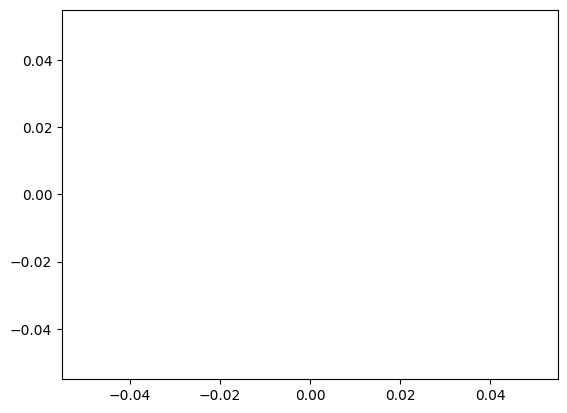

In [32]:
plt.plot(qlearning_valores[1])

### Comprobar politicas

In [ ]:
def comprueba_politica_determinista(politica:np.ndarray, num_episodios:int = 5) -> None:
    env.reset()
    q_valores = np.zeros((NUM_INTERVALOS, NUM_INTERVALOS, NUM_INTERVALOS, NUM_ACCIONES))
    ultimos100retornos = []
    cnt = 0
    while cnt < num_episodios:
        cnt += 1
        retorno = 0
        num_pasos = 0
        completado = False
        env.reset()
        env.max_steps = 200
        estado_actual = discretizar_estado(obs)
        while not completado:
            accion_escogida = get_accion_epsilon_greedy(q_valores[*estado_actual, :], 0)
            observacion, recompensa, terminated, truncated, info = env.step(np.array([acciones[accion_escogida]]))
            nuevo_estado = discretizar_estado(observacion)
            retorno += recompensa
            num_pasos += 1
            completado = terminated or truncated
            estado_actual = nuevo_estado
        ultimos100retornos.append(retorno)
        string_retornos100 = ''
        if len(ultimos100retornos)==101: # ... y si hay ya más de 100...
            ultimos100retornos.pop(0) # ...quitamos el más antiguo (para tener siempre 100, no más)...
            #... y preparamos el mensaje para mostrar la media de los retornos
            string_retornos100=f'(retorno medio de {np.mean(ultimos100retornos)} en los últimos 100 episodios)'
        # Mostramos el mensaje tras cada episodio
        print(f'Terminado episodio {cnt} con retorno {retorno} en {num_pasos} pasos {string_retornos100}')
comprueba_politica_determinista(qlearning_valores)